<a href="https://www.kaggle.com/code/shreeyashah/imdb-reviews?scriptVersionId=319287465" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras

2026-05-14 10:22:32.082295: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778754152.305690      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778754152.356859      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778754152.779349      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778754152.779398      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778754152.779401      23 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df['review'] = df['review'].str.lower()
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [5]:
import re
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'', text)

In [6]:
df['review'] = df['review'].apply(remove_html_tags)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [7]:
import string,time
exclude = string.punctuation
def remove_punc(text):
    return text.translate(str.maketrans('', '', exclude))

In [8]:
df['review'] = df['review'].apply(remove_punc)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [9]:
X = df.iloc[:,0]
y = df.iloc[:,1]

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words = 12000, oov_token='<nothing>')

In [13]:
tokenizer.fit_on_texts(X_train)

In [14]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

In [15]:
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [16]:
total_words = total_words = len(tokenizer.word_index) + 1
print(total_words)

193679


In [17]:
max_len = max([len(x) for x in X_train_seq])
print(max_len)

2450


In [18]:
from keras.utils import pad_sequences
X_train_seq = pad_sequences(X_train_seq, padding = 'post', maxlen = max_len)
X_test_seq = pad_sequences(X_test_seq, padding = 'post', maxlen = max_len)

In [19]:
from tensorflow.keras import layers
from keras.layers import Embedding, Dense, LSTM, Bidirectional, Dropout
from keras.models import Sequential

In [20]:
model = Sequential()
model.add(Embedding(total_words , output_dim = 128, input_length = max_len))
model.add(Bidirectional(LSTM(128, dropout=0.2)))
model.add(Dropout(0.3))
model.add(Dense(64, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778754191.468473      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [22]:
model = Sequential()
model.add(Embedding(total_words , output_dim = 100, input_length=250))
model.add(Bidirectional(LSTM(150)))
model.add(Dense(1, activation = 'sigmoid'))

In [23]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [24]:
history = model.fit(X_train_seq, y_train, epochs = 10, validation_split = 0.2, callbacks = [early_stop])

Epoch 1/10


I0000 00:00:1778754196.343985      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 271s 266ms/step - accuracy: 0.6250 - loss: 0.6346 - val_accuracy: 0.8115 - val_loss: 0.4533
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 265s 265ms/step - accuracy: 0.8083 - loss: 0.4477 - val_accuracy: 0.8313 - val_loss: 0.3993
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 266s 266ms/step - accuracy: 0.8994 - loss: 0.2551 - val_accuracy: 0.8876 - val_loss: 0.2685
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 266s 266ms/step - accuracy: 0.9329 - loss: 0.1822 - val_accuracy: 0.8964 - val_loss: 0.2635
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 265s 265ms/step - accuracy: 0.9579 - loss: 0.1247 - val_accuracy: 0.8914 - val_loss: 0.2830
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 265s 265ms/step - accuracy: 0.9716 - loss: 0.0877 - val_accuracy: 0.8940 - val_loss: 0.3006


In [25]:
y_pred = model.predict(X_test_seq)

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step


In [26]:
y_pred = np.where(y_pred>=0.5,1 , 0)

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8936

In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[4509,  491],
       [ 573, 4427]])

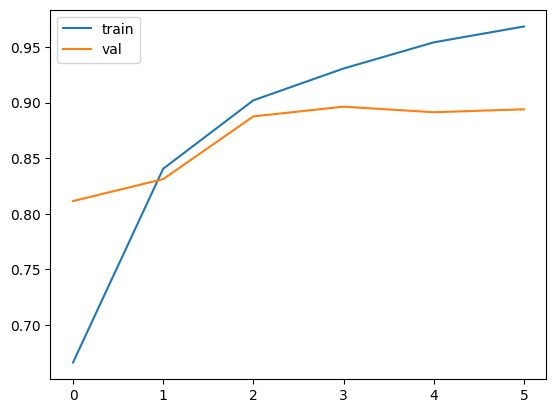

In [29]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label = 'train')
plt.plot(history.history['val_accuracy'], label = 'val')
plt.legend()
plt.show()

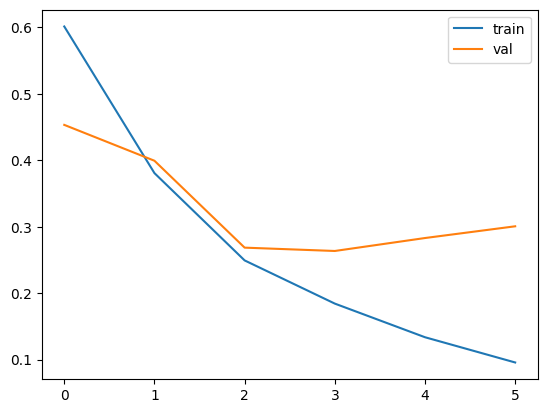

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'val')
plt.legend()
plt.show()